In [65]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder,OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_selection import SelectKBest,RFECV,f_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import  LinearRegression
from sklearn.metrics import r2_score,mean_squared_error
sns.set_theme(style="darkgrid")
import warnings
warnings.filterwarnings("ignore")

In [66]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
data = pd.read_csv("/kaggle/input/datasets/jigarkhadka/energy/Energy_consumption.csv")

# Feature engineering from Timestamp
data["Timestamp"] = pd.to_datetime(data["Timestamp"])
data["Month"] = data["Timestamp"].dt.month_name()
data["IsWeekend"] = data["DayOfWeek"].apply(lambda x: 1 if x in ["Sunday", "Saturday"] else 0)

# Define X without Timestamp and target column, keeping data intact
X = data.drop(columns=["EnergyConsumption", "Timestamp"])
y = data["EnergyConsumption"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## **Helper Functions**

In [67]:
# Function to optimize 'k'
def select_k(X,y,estimator,scoring,func,k_range=range(1,5)):
  global preprocessor
  optimize = Pipeline(steps=[("preprocessor", preprocessor),
                                ("selector",SelectKBest(func)),
                                ("regressor", estimator)])

  param_grid = {'selector__k' : k_range}
  grid = GridSearchCV(optimize, param_grid=param_grid, cv=5, scoring=scoring)
  grid.fit(X, y)
  return grid.best_params_.get("selector__k")

# Function to compare 'models'
models_table = pd.DataFrame(columns=["Model","Type","R2","RMSE"])
def select_model(estimator,X,y,features,type="Baseline"):
  global models_table
  global X_test
  global y_test
  global preprocessor
  X_processed = preprocessor.fit_transform(X)
  X_test_processed = preprocessor.transform(X_test)
  model = estimator
  model.fit(X_processed[features],y)
  y_pred = model.predict(X_test_processed[features])
  r2 = r2_score(y_test,y_pred)
  rmse = mean_squared_error(y_test,y_pred)**0.5
  return [str(estimator).split("(")[0],
          type,
          r2,
          rmse]

# **Exploratory Data Analysis(EDA)**

#### Understanding the data

In [68]:
# Checking datatypes and null values
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Timestamp          1000 non-null   datetime64[ns]
 1   Temperature        1000 non-null   float64       
 2   Humidity           1000 non-null   float64       
 3   SquareFootage      1000 non-null   float64       
 4   Occupancy          1000 non-null   int64         
 5   HVACUsage          1000 non-null   object        
 6   LightingUsage      1000 non-null   object        
 7   RenewableEnergy    1000 non-null   float64       
 8   DayOfWeek          1000 non-null   object        
 9   Holiday            1000 non-null   object        
 10  EnergyConsumption  1000 non-null   float64       
 11  Month              1000 non-null   object        
 12  IsWeekend          1000 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(2), object(5)
memory usa

In [69]:
#Checking a subset of data
data.head(10)

,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,DayOfWeek,Holiday,EnergyConsumption,Month,IsWeekend
0,2022-01-01 00:00:00,25.139433,43.431581,1565.693999,5,On,Off,2.774699,Monday,No,75.364373,January,0
1,2022-01-01 01:00:00,27.731651,54.225919,1411.064918,1,On,On,21.831384,Saturday,No,83.401855,January,1
2,2022-01-01 02:00:00,28.704277,58.907658,1755.715009,2,Off,Off,6.764672,Sunday,No,78.270888,January,1
3,2022-01-01 03:00:00,20.080469,50.371637,1452.316318,1,Off,On,8.623447,Wednesday,No,56.519850,January,0
4,2022-01-01 04:00:00,23.097359,51.401421,1094.130359,9,On,Off,3.071969,Friday,No,70.811732,January,0
5,2022-01-01 05:00:00,29.576037,36.824263,1871.709180,6,Off,Off,17.626690,Sunday,Yes,84.321885,January,1
6,2022-01-01 06:00:00,25.131167,35.709622,1607.001228,6,On,Off,24.264702,Friday,Yes,76.165791,January,0
7,2022-01-01 07:00:00,23.182844,31.679920,1633.955330,8,Off,Off,27.517099,Thursday,Yes,74.131906,January,0
8,2022-01-01 08:00:00,25.391999,46.399364,1240.309224,6,On,Off,2.307595,Sunday,No,78.206236,January,1
9,2022-01-01 09:00:00,22.212549,32.418464,1705.420336,1,On,Off,29.140071,Tuesday,No,77.992214,January,0


In [70]:
# Checking unique values in data
data.nunique().sort_values(ascending=False)

Timestamp            1000
Temperature          1000
Humidity             1000
SquareFootage        1000
RenewableEnergy      1000
EnergyConsumption    1000
Occupancy              10
DayOfWeek               7
LightingUsage           2
HVACUsage               2
Holiday                 2
Month                   2
IsWeekend               2
dtype: int64

In [71]:
# Statistical Summary
data.describe() #only numerical values

,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,RenewableEnergy,EnergyConsumption,IsWeekend
count,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2022-01-21 19:29:59.999999744,24.982026,45.395412,1500.052488,4.581000,15.132813,77.055873,0.297000
min,2022-01-01 00:00:00,20.007565,30.015975,1000.512661,0.000000,0.006642,53.263278,0.000000
25%,2022-01-11 09:45:00,22.645070,38.297722,1247.108548,2.000000,7.628385,71.544690,0.000000
50%,2022-01-21 19:30:00,24.751637,45.972116,1507.967426,5.000000,15.072296,76.943696,0.000000
75%,2022-02-01 05:15:00,27.418174,52.420066,1740.340165,7.000000,22.884064,82.921742,1.000000
max,2022-02-11 15:00:00,29.998671,59.969085,1999.982252,9.000000,29.965327,99.201120,1.000000
std,NaN,2.836850,8.518905,288.418873,2.865598,8.745917,8.144112,0.457165


#### Data Quality Check

In [72]:
# Checking for Null or Duplicate values
print(data.isnull().sum().rename('Null Count').sort_values(ascending=False))
duplicates = data.duplicated().sum()
print("Number of duplicate rows", duplicates)

Timestamp            0
Temperature          0
Humidity             0
SquareFootage        0
Occupancy            0
HVACUsage            0
LightingUsage        0
RenewableEnergy      0
DayOfWeek            0
Holiday              0
EnergyConsumption    0
Month                0
IsWeekend            0
Name: Null Count, dtype: int64
Number of duplicate rows 0


In [73]:
# Separating Categorical and Numerical data
categorical_data = data.select_dtypes(include=['object'])
numerical_data = data.select_dtypes(exclude=['object','datetime64[ns]'])
print("Number of categorical columns", categorical_data.columns.size)

print(('\n').join(categorical_data.columns.to_list()),"\n")
print("Number of numerical columns", numerical_data.columns.size)
print(('\n').join(numerical_data.columns.to_list()))

Number of categorical columns 5
HVACUsage
LightingUsage
DayOfWeek
Holiday
Month 

Number of numerical columns 7
Temperature
Humidity
SquareFootage
Occupancy
RenewableEnergy
EnergyConsumption
IsWeekend


## Breakdown
In the analysis so far, we've discovered that the data consists of no null values or any duplicate values. This will be helpful in training the model because the data quality is good.

We have 5 categorical columns and 6 numerical columns, with our target being a numerical column. Hence, we will be comparing two models: Linear Regression and Random Forest, to see which one makes better predictions.

However, before doing that we must check the data for any more patterns or useful insights.

## **Visualizing the data**

#### Categorical Data


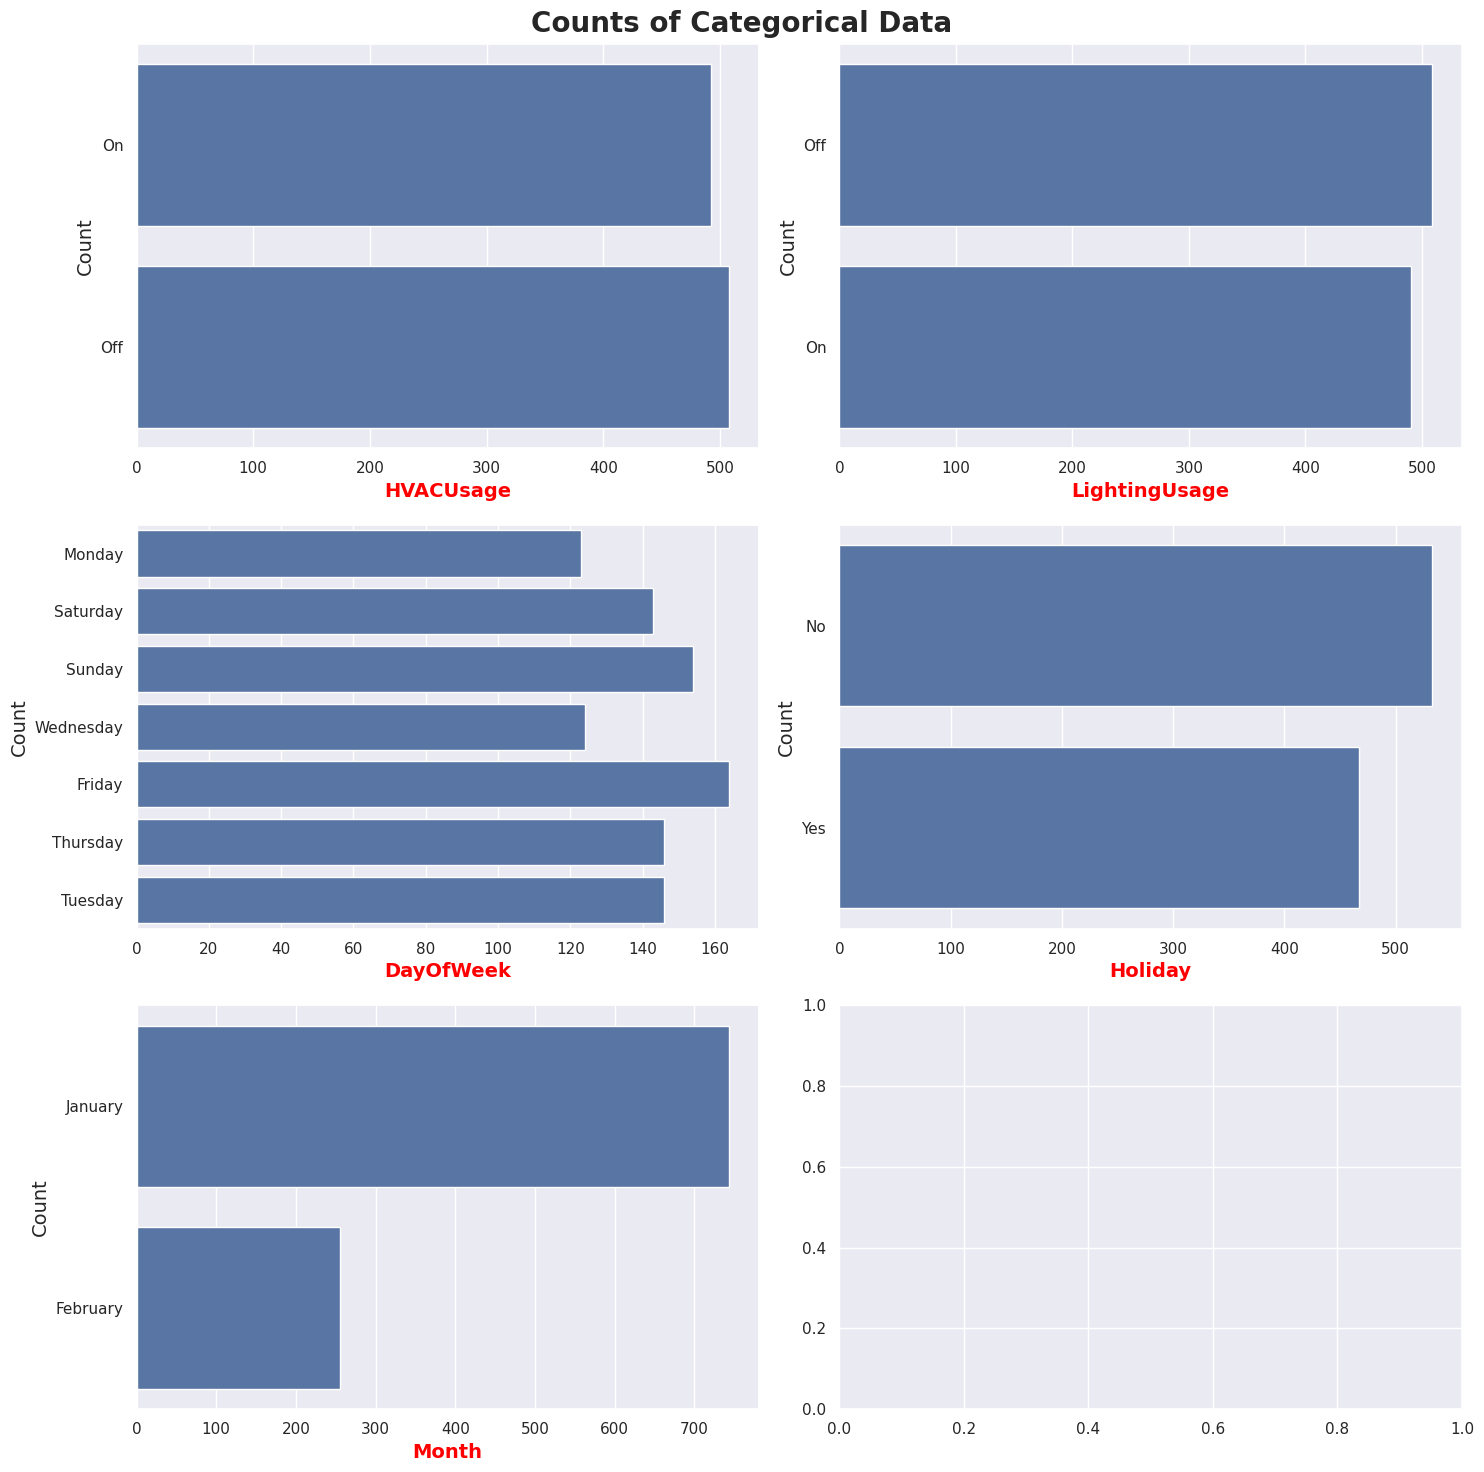

In [74]:
# Plotting categorical
figure, ax = plt.subplots(3,2,figsize=(15, 15))
i = 0
j = 0
for column in categorical_data.columns:
   sns.countplot(data=data[column], ax=ax[j,i])
   ax[j,i].set_xlabel(column,fontsize=14,weight="bold",color="red")
   ax[j,i].set_ylabel("Count",fontsize=14)
   if i < 1:
    i += 1
   elif i == 1:
    i = 0
    j += 1
   elif j == 3:
    break

figure.suptitle("Counts of Categorical Data", fontsize=20,weight="bold")
plt.tight_layout()
plt.show()

**Time-Series Plot(Energy Consumption)**

Text(0, 0.5, 'Energy Consumption')

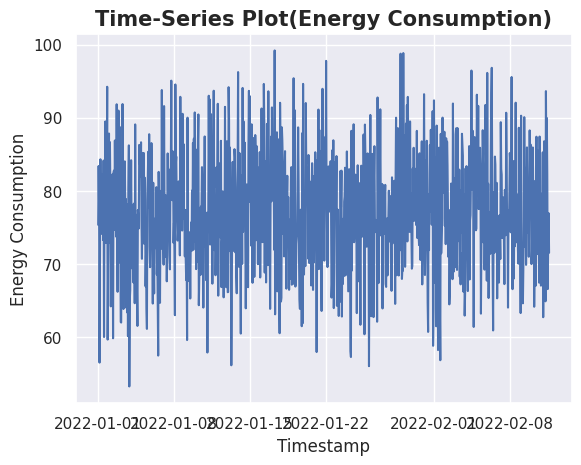

In [75]:
sns.lineplot(data=data,x=data["Timestamp"],y=data["EnergyConsumption"])
plt.title('Time-Series Plot(Energy Consumption)',fontsize=15,weight="bold")
plt.xlabel('Timestamp')
plt.ylabel('Energy Consumption')

**Energy Consumption(HVAC and Lighting)**

In [76]:
# Energy Consumption when HVAC is off
print("Energy Consumption HVAC -- OFF")
print(data.loc[data["HVACUsage"]=="Off", "EnergyConsumption"].describe(), "\n")

# Energy Consumption when HVAC is on
print("Energy Consumption HVAC -- ON")
print(data.loc[data["HVACUsage"]=="On", "EnergyConsumption"].describe(), "\n")

hvacoff = data.loc[data["HVACUsage"]=="Off", "EnergyConsumption"].mean().round(2)
hvacon = data.loc[data["HVACUsage"]=="On", "EnergyConsumption"].mean().round(2)

Energy Consumption HVAC -- OFF
count    508.000000
mean      74.761057
std        7.986594
min       53.263278
25%       69.325134
50%       74.417169
75%       80.430330
max       98.843756
Name: EnergyConsumption, dtype: float64 

Energy Consumption HVAC -- ON
count    492.000000
mean      79.425316
std        7.616502
min       59.608902
25%       74.212691
50%       78.731899
75%       84.691476
max       99.201120
Name: EnergyConsumption, dtype: float64 



In [77]:
# Energy Consumption when Lighting is off
print("Energy Consumption Lighting -- OFF")
print(data.loc[data["LightingUsage"]=="Off", "EnergyConsumption"].describe(), "\n")

# Energy Consumption when Lighting is on
print("Energy Consumption Lighting -- ON")
print(data.loc[data["LightingUsage"]=="On", "EnergyConsumption"].describe(), "\n")

lightoff = data.loc[data["LightingUsage"]=="Off", "EnergyConsumption"].mean().round(2)
lighton = data.loc[data["LightingUsage"]=="On", "EnergyConsumption"].mean().round(2)

Energy Consumption Lighting -- OFF
count    509.000000
mean      76.308970
std        8.143900
min       56.038163
25%       70.547261
50%       76.555025
75%       82.306692
max       97.773488
Name: EnergyConsumption, dtype: float64 

Energy Consumption Lighting -- ON
count    491.000000
mean      77.830157
std        8.079929
min       53.263278
25%       72.055892
50%       77.553946
75%       83.293315
max       99.201120
Name: EnergyConsumption, dtype: float64 



In [78]:
# Energy Consumption when Lighting and HVAC is off
print("Energy Consumption when both Lighting and HVAC -- OFF")
print(data.loc[(data["LightingUsage"]=="Off") & (data["HVACUsage"]=="Off"), "EnergyConsumption"].describe(), "\n")

# Energy Consumption when Lighting and HVAC is on
print("Energy Consumption when both Lighting and HVAC -- ON")
print(data.loc[(data["LightingUsage"]=="On") & (data["HVACUsage"]=="On"), "EnergyConsumption"].describe(), "\n")

bothon = data.loc[(data["LightingUsage"]=="On") & (data["HVACUsage"]=="On"), "EnergyConsumption"].mean().round(2)
bothoff = data.loc[(data["LightingUsage"]=="Off") & (data["HVACUsage"]=="Off"), "EnergyConsumption"].mean().round(2)

Energy Consumption when both Lighting and HVAC -- OFF
count    246.000000
mean      73.918075
std        8.152627
min       56.038163
25%       67.703480
50%       73.992567
75%       79.199525
max       97.773488
Name: EnergyConsumption, dtype: float64 

Energy Consumption when both Lighting and HVAC -- ON
count    229.000000
mean      80.435965
std        7.654636
min       61.130943
25%       74.843381
50%       80.132973
75%       86.085270
max       99.201120
Name: EnergyConsumption, dtype: float64 



### Plotting above information

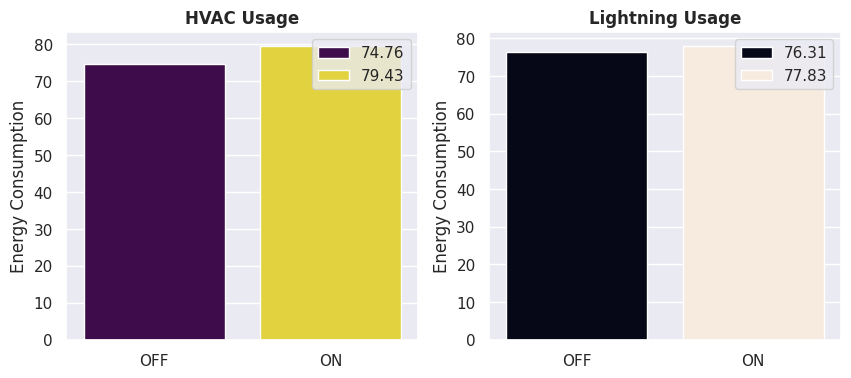

In [79]:
# HVAC
figure, ax = plt.subplots(1,2,figsize=(10,4))
sns.barplot(x=["OFF","ON"], y=[hvacoff, hvacon],ax=ax[0], palette="viridis",hue=[hvacoff,hvacon])
ax[0].set_title("HVAC Usage",weight="bold")
ax[0].set_ylabel("Energy Consumption")

#Lighting
sns.barplot(x=["OFF","ON"], y=[lightoff, lighton],ax=ax[1], palette="rocket",hue=[lightoff,lighton])
ax[1].set_title("Lightning Usage",weight="bold")
ax[1].set_ylabel("Energy Consumption")

plt.savefig("hvac_and_lighting_bar.png",bbox_inches="tight",dpi=300)

Text(0, 0.5, 'Energy Consumption')

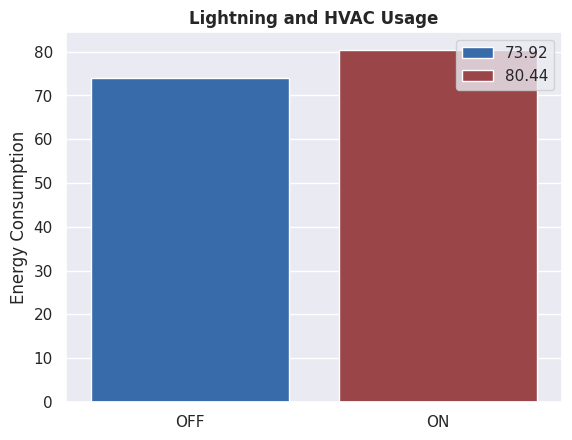

In [80]:
#Both Lighting and HVAC Usage
sns.barplot(x=["OFF","ON"], y=[bothoff, bothon], palette="vlag",hue=[bothoff,bothon])
plt.title("Lightning and HVAC Usage",weight="bold")
plt.ylabel("Energy Consumption")

**Energy Consumption Based on Month**

In [81]:
#Creating a new column ["Month"] that has the month name
months = data["Timestamp"].dt.month_name()
data["Month"] = months
data["Month"].unique()

array(['January', 'February'], dtype=object)

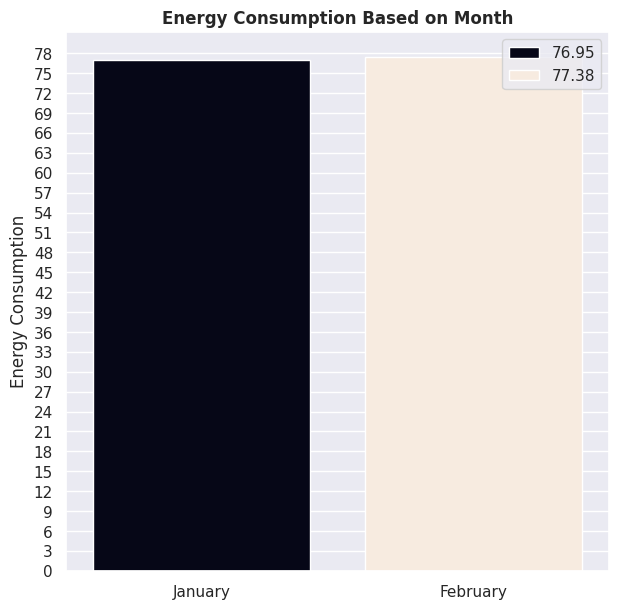

In [82]:
# Energy Consumption January Vs. February
jan_energy = data.loc[data["Month"]=="January", "EnergyConsumption"].mean().round(2)
feb_energy = data.loc[data["Month"]=="February", "EnergyConsumption"].mean().round(2)

# Plotting
plt.figure(figsize=(7,7))
sns.barplot(x=["January","February"], y=[jan_energy, feb_energy], palette="rocket",hue=[jan_energy, feb_energy])
plt.title("Energy Consumption Based on Month",weight="bold")
plt.ylabel("Energy Consumption")
plt.yticks(range(0,80,3))
plt.show()

### **Breakdown**

The dataset contains observations from January and February, with relatively small differences in average energy consumption between the two months. The exact relationship will be tested below.

HVACUsage and LightingUsage both have an effect on EnergyConsumption, as intended.


# **Feature Engineering**


##### Feature Transformation
Although we already added a feature ['Month'] earlier. Let's check for any more.
Since we figured out that combing both HVAC and Lighting Usage has a effect on EnergyConsumption.<br> We will create a new feature called HLUsage that will be **'ON'** if BOTH are **'ON'** and **'OFF'** if ONE is **'OFF'**

In [83]:
# Adding a feature called ['HLUsage']
# Combines both HVACUsage and LightingUsage
X_train['HLUsage'] = ((X_train["HVACUsage"] == "On") & (X_train["LightingUsage"] == "On")).astype(int)
X_test['HLUsage'] = ((X_test["HVACUsage"] == "On") & (X_test["LightingUsage"] == "On")).astype(int)

## Preprocessing
##### Feature Encoding

In [84]:

# Building a pipeline to encode features + scaling
# Ordinal --> Ordinal Encoder, Nominal --> OneHotEncoder
nominal = ["DayOfWeek","Month"]
ordinal = [col for col in categorical_data.columns if col not in nominal]
numerical_columns_to_scale = numerical_data.columns.drop("EnergyConsumption").to_list()
preprocessor = ColumnTransformer(transformers=[("ordinal", OrdinalEncoder(), ordinal),
                                               ("nominal", OneHotEncoder(sparse_output=False,handle_unknown="ignore"), nominal),
                                               ("scaler", MinMaxScaler(), numerical_columns_to_scale)],
                                 remainder="passthrough")
preprocessor.set_output(transform="pandas")
preprocessor.fit(X_train)

ColumnTransformer(remainder='passthrough',
                  transformers=[('ordinal', OrdinalEncoder(),
                                 ['HVACUsage', 'LightingUsage', 'Holiday']),
                                ('nominal',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['DayOfWeek', 'Month']),
                                ('scaler', MinMaxScaler(),
                                 ['Temperature', 'Humidity', 'SquareFootage',
                                  'Occupancy', 'RenewableEnergy',
                                  'IsWeekend'])])

# **Feature Selection**

scaler__Temperature             0.701886
ordinal__HVACUsage              0.268269
remainder__HLUsage              0.211961
scaler__Occupancy               0.197474
scaler__RenewableEnergy         0.109176
scaler__Humidity                0.097109
ordinal__LightingUsage          0.078558
ordinal__Holiday                0.059065
nominal__Month_January          0.049442
nominal__Month_February         0.049442
nominal__DayOfWeek_Tuesday      0.048505
scaler__IsWeekend               0.040096
nominal__DayOfWeek_Saturday     0.032554
nominal__DayOfWeek_Monday       0.032239
scaler__SquareFootage           0.023004
nominal__DayOfWeek_Sunday       0.019063
nominal__DayOfWeek_Friday       0.016135
nominal__DayOfWeek_Thursday     0.013338
nominal__DayOfWeek_Wednesday    0.002634
dtype: float64


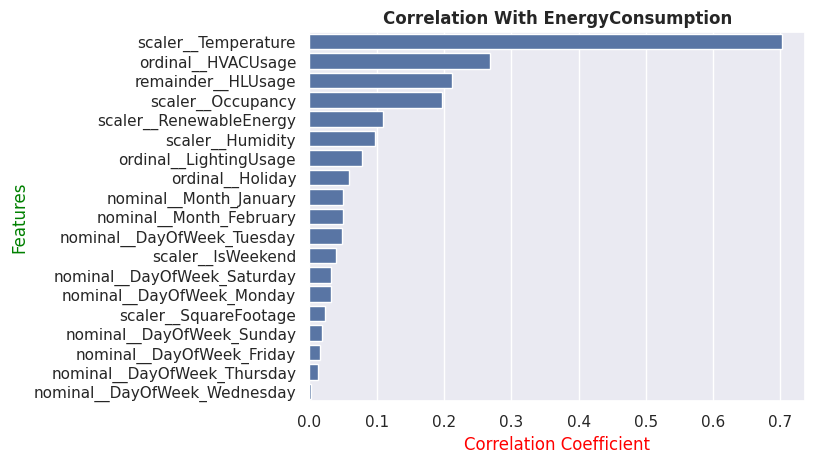

In [85]:
# Checking correlation with target variable
correlation = preprocessor.transform(X_train).corrwith(y_train)
correlation = correlation.abs().sort_values(ascending=False)
print(correlation)
sns.barplot(x=correlation.values,y=correlation.index)
plt.title("Correlation With EnergyConsumption", weight="bold")
plt.xlabel("Correlation Coefficient", color="red")
plt.ylabel("Features", color="green")
plt.savefig("correlation_bar.png",bbox_inches="tight",dpi=300)
plt.show()

HVACUsage, Temperature and Occupancy seem to be the biggest factor determining EnergyConsumption which is self explanatory.

HVACUsage means that energy is being consumed.
Temperature also affects Energy consumption because during hotter weathers people tend to use fans, AC and heaters on colder weather.

Higher Occupancy means more number of people means more energy consumption.

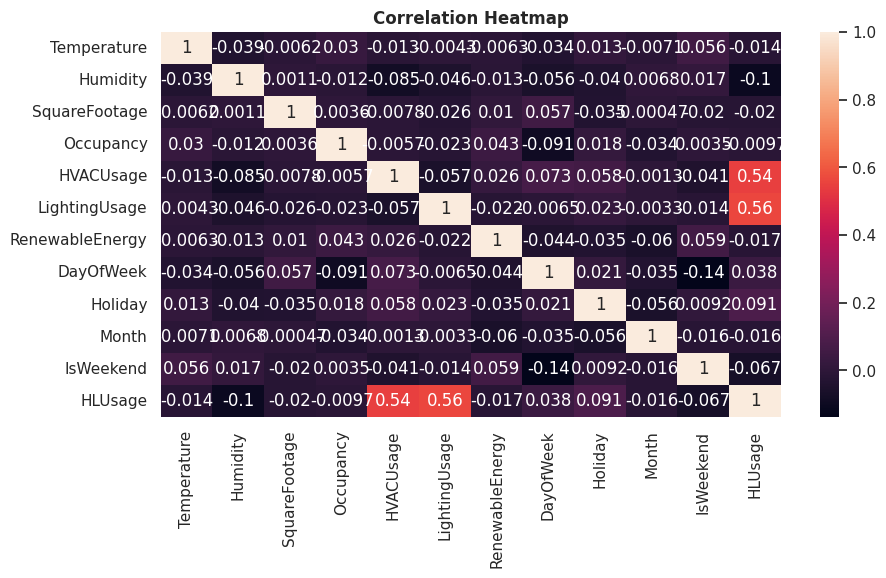

In [86]:
# Correlation matrix
# Ordinal Encoding the data(OneHot Encoding explodes the data making it hard to read)
corr_data = X_train.copy()
corr_data_categories = ['HVACUsage', 'LightingUsage', 'DayOfWeek', 'Holiday','Month']
encoder = OrdinalEncoder()
corr_data[corr_data_categories] = encoder.fit_transform(corr_data[corr_data_categories])

corr_matrix = corr_data.corr()
plt.figure(figsize=(10,5))
sns.heatmap(data=corr_matrix,annot=True)
plt.title("Correlation Heatmap", weight="bold")
plt.savefig("correlation_heatmap.png",bbox_inches="tight",dpi=300)
plt.show()

**F-Regression Test**

In [87]:
# Using F-Test Regression for Feature Selection
# Optimizing 'k' for SelectKBest in LinearRegression
k_linear = select_k(func=f_regression,scoring='r2',X=X_train,y=y_train,k_range=range(1,10),estimator=LinearRegression())

#Optimizing 'k' for RandomForestRegressor
k_random = select_k(func=f_regression,scoring='r2',X=X_train,y=y_train,k_range=range(1,10),estimator=RandomForestRegressor(random_state=42))

In [88]:
 # Using F-Test To Find Optimal Features
X_for_f_test = preprocessor.transform(X_train)
linear_selector = SelectKBest(f_regression, k=k_linear)
random_selector = SelectKBest(f_regression, k=k_random)
linear_selector.fit_transform(X_for_f_test, y_train)
random_selector.fit_transform(X_for_f_test,y_train)
f_test_linear = X_for_f_test.columns[linear_selector.get_support()].to_list()
f_test_random = X_for_f_test.columns[random_selector.get_support()].to_list()
print(f_test_linear)
print(f_test_random)

['ordinal__HVACUsage', 'ordinal__LightingUsage', 'scaler__Temperature', 'scaler__Humidity', 'scaler__Occupancy', 'scaler__RenewableEnergy', 'remainder__HLUsage']
['ordinal__HVACUsage', 'ordinal__LightingUsage', 'ordinal__Holiday', 'nominal__Month_January', 'scaler__Temperature', 'scaler__Humidity', 'scaler__Occupancy', 'scaler__RenewableEnergy', 'remainder__HLUsage']


In [89]:
# Using RFECV for feature selection
rfecv_linear = RFECV(estimator=LinearRegression(), step=1, cv=5, scoring='r2')
rfecv_linear.fit(X_for_f_test, y_train)
rfecv_random = RFECV(estimator=RandomForestRegressor(random_state=42),step=1,cv=5,scoring='r2')
rfecv_random.fit(X_for_f_test,y_train)

RFECV(cv=5, estimator=RandomForestRegressor(random_state=42), scoring='r2')

In [90]:
# Printing the features selected by RFECV
rfecv_linear_features = X_for_f_test.columns[rfecv_linear.get_support()].to_list()
rfecv_random_features = X_for_f_test.columns[rfecv_random.get_support()].to_list()
print("Linear Regression")
print(f"Optimal Number of Features:- {rfecv_linear.n_features_}")
print(f"Features:-\n {rfecv_linear_features}\n")
print("Random Forest Regressor")
print(f"Optimal Number of Features:- {rfecv_random.n_features_}")
print(f"Features:-\n {rfecv_random_features}")

Linear Regression
Optimal Number of Features:- 5
Features:-
 ['ordinal__HVACUsage', 'ordinal__LightingUsage', 'scaler__Temperature', 'scaler__Occupancy', 'scaler__RenewableEnergy']

Random Forest Regressor
Optimal Number of Features:- 18
Features:-
 ['ordinal__HVACUsage', 'ordinal__LightingUsage', 'ordinal__Holiday', 'nominal__DayOfWeek_Friday', 'nominal__DayOfWeek_Monday', 'nominal__DayOfWeek_Saturday', 'nominal__DayOfWeek_Thursday', 'nominal__DayOfWeek_Tuesday', 'nominal__DayOfWeek_Wednesday', 'nominal__Month_February', 'nominal__Month_January', 'scaler__Temperature', 'scaler__Humidity', 'scaler__SquareFootage', 'scaler__Occupancy', 'scaler__RenewableEnergy', 'scaler__IsWeekend', 'remainder__HLUsage']


### **Creating Baseline Models**

In [91]:
#Defining ALL Features for baseline models
all_features = preprocessor.fit_transform(X_train).columns.to_list()
# Baseline Linear Regression
baseline_lreg = select_model(estimator=LinearRegression(),X=X_train,y=y_train,features=all_features)
models_table.loc[len(models_table)] = baseline_lreg

#Baseline RandomForestRegressor
baseline_rforest = select_model(estimator=RandomForestRegressor(random_state=42),X=X_train,y=y_train,features=all_features)
models_table.loc[len(models_table)] = baseline_rforest


### **Models With Selected Features**




In [92]:
# F-Test Linear Regression
f_test_lreg = select_model(estimator=LinearRegression(),X=X_train,y=y_train,features=f_test_linear,type="F-Test")
models_table.loc[len(models_table)] = f_test_lreg

# F-Test RandomForest
f_test_rforest = select_model(estimator=RandomForestRegressor(random_state=42),X=X_train,y=y_train,features=f_test_random,type="F-Test")
models_table.loc[len(models_table)] = f_test_rforest

# RFECV Linear Regression
rfecv_test_lreg = select_model(estimator=LinearRegression(),X=X_train,y=y_train,features=rfecv_linear_features,type="RFECV")
models_table.loc[len(models_table)] = rfecv_test_lreg

rfecv_test_rforest = select_model(estimator=RandomForestRegressor(random_state=42),X=X_train,y=y_train,features=rfecv_random_features,type="RFECV")
models_table.loc[len(models_table)] = rfecv_test_rforest



In [93]:
# Viewing the models table to check the best model
models_table

,Model,Type,R2,RMSE
0,LinearRegression,Baseline,0.592531,5.166156
1,RandomForestRegressor,Baseline,0.536628,5.509156
2,LinearRegression,F-Test,0.599533,5.121578
3,RandomForestRegressor,F-Test,0.531130,5.541743
4,LinearRegression,RFECV,0.597938,5.131765
5,RandomForestRegressor,RFECV,0.533965,5.524967


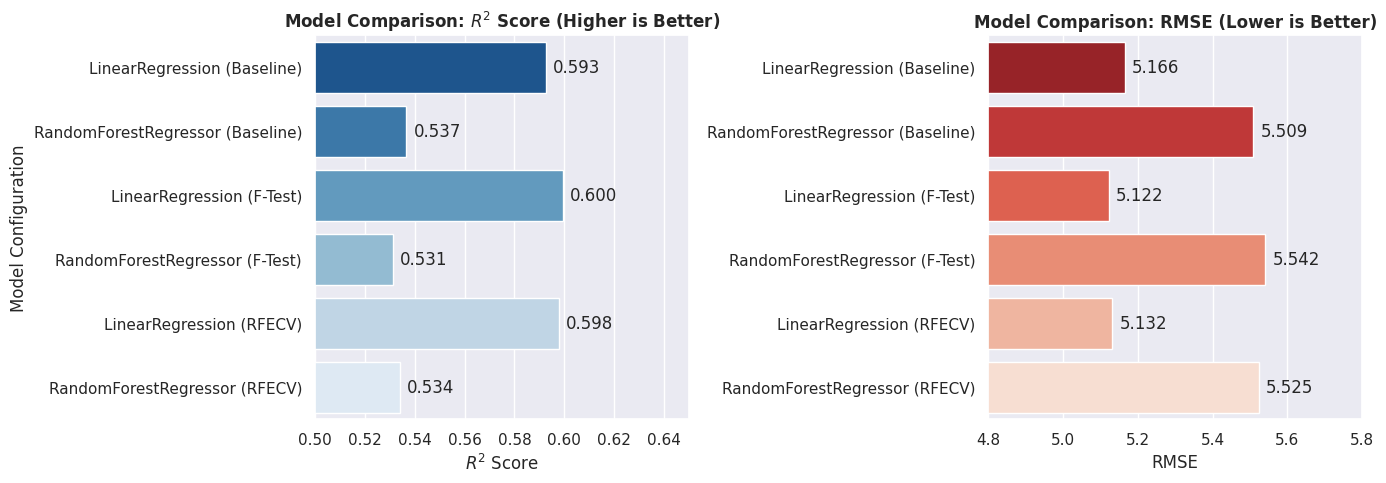

In [94]:
models_table["Model_Variant"] = (
    models_table["Model"] + " (" + models_table["Type"] + ")"
)

# Set up side-by-side plots for R2 and RMSE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot R2 Scores
sns.barplot(
    data=models_table,
    x="R2",
    y="Model_Variant",
    ax=axes[0],
    palette="Blues_r",
    hue="Model_Variant",
    legend=False,
)
axes[0].set_title("Model Comparison: $R^2$ Score (Higher is Better)", weight="bold")
axes[0].set_xlabel("$R^2$ Score")
axes[0].set_ylabel("Model Configuration")
axes[0].set_xlim(0.5, 0.65)  # Adjust axis range for clarity

# Annotate R2 bar values
for p in axes[0].patches:
    width = p.get_width()
    axes[0].annotate(
        f"{width:.3f}",
        (width, p.get_y() + p.get_height() / 2.0),
        ha="left",
        va="center",
        xytext=(5, 0),
        textcoords="offset points",
    )

# Plot RMSE Scores
sns.barplot(
    data=models_table,
    x="RMSE",
    y="Model_Variant",
    ax=axes[1],
    palette="Reds_r",
    hue="Model_Variant",
    legend=False,
)
axes[1].set_title("Model Comparison: RMSE (Lower is Better)", weight="bold")
axes[1].set_xlabel("RMSE")
axes[1].set_ylabel("")
axes[1].set_xlim(4.8, 5.8)  # Adjust axis range for clarity

# Annotate RMSE bar values
for p in axes[1].patches:
    width = p.get_width()
    axes[1].annotate(
        f"{width:.3f}",
        (width, p.get_y() + p.get_height() / 2.0),
        ha="left",
        va="center",
        xytext=(5, 0),
        textcoords="offset points",
    )

plt.tight_layout()

# Save image for your GitHub README
plt.savefig("model_performance_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

#### Best Model — 
Linear Regression with F-test Feature Selection

## **Hyperparameter Tuning**
#### Linear Regression has no major hyperparameters requiring tuning for this project. Based on the model comparison, Linear Regression with F-test feature selection achieved the best performance among the evaluated approaches.

## **Final Model**

In [95]:
final_model = Pipeline(steps=[("preprocessor", preprocessor),
                              ("selector", SelectKBest(f_regression, k=k_linear)),
                              ("model", LinearRegression())])

final_model.fit(X_train,y_train)
y_pred = final_model.predict(X_test)

print("--Linear Regression--")
print("**Metrics**")
print(f"R2 Score: {r2_score(y_test,y_pred)}")
print(f"--> The model explains {(r2_score(y_test,y_pred) * 100):.2f}% of the variance in Energy Consumption.\n")
print(f"RMSE: {mean_squared_error(y_test,y_pred)**0.5}")
print(f"--> The model is off by approx. {mean_squared_error(y_test,y_pred)**0.5:.2f} units on average")

--Linear Regression--
**Metrics**
R2 Score: 0.5995326259532217
--> The model explains 59.95% of the variance in Energy Consumption.

RMSE: 5.121578190036728
--> The model is off by approx. 5.12 units on average


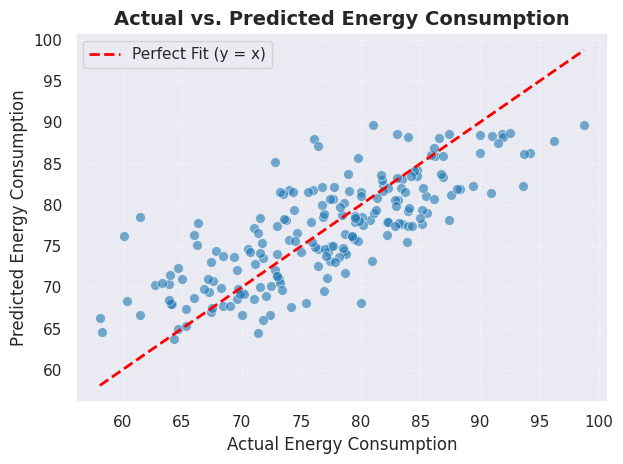

In [96]:
# Actual Vs Predicted Values
sns.scatterplot(
    x=y_test,
    y=y_pred,
    alpha=0.6,
    color="#1f77b4",
    edgecolor="w",
    s=50
)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Perfect Fit (y = x)"
)

plt.title("Actual vs. Predicted Energy Consumption", fontsize=14, weight="bold")
plt.xlabel("Actual Energy Consumption", fontsize=12)
plt.ylabel("Predicted Energy Consumption", fontsize=12)
plt.legend(loc="upper left")
plt.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()

# Save figure for GitHub README
plt.savefig("actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()